# ML1 – Lab Test 3: Reinforcement Learning — Forest Rescue Environment

**Dataset:** forest_rescue_gridworld.xls  
**Deliverable:** Jupyter Notebook (.ipynb)

This notebook implements a reinforcement learning pipeline for the 5×5 Forest Rescue GridWorld environment. It includes environment analysis, MDP formulation, TD Learning, Q-Learning, policy extraction, exploration vs exploitation, SARSA, model comparison, and final interpretation.


## Setup — Import Libraries

In [1]:
# Core libraries
import os
import warnings
from pathlib import Path

# Keep numerical backends stable on small/student machines
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot configuration
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Setup — Load Dataset

In [2]:
DATA_PATH = Path("forest_rescue_gridworld.xls")

# The file is in the same folder as the notebook.
# Even if the extension is .xls, the content is CSV-formatted text, so read_csv is used.
df = pd.read_csv(DATA_PATH)

# Clean data types
df["state"] = df["state"].astype(int)
df["next_state"] = df["next_state"].astype(int)
df["reward"] = df["reward"].astype(float)
df["done"] = df["done"].astype(int)

# Keep actions in a fixed order
action_order = ["up", "down", "left", "right"]
df["action"] = pd.Categorical(df["action"], categories=action_order, ordered=True)
df = df.sort_values(["state", "action"]).reset_index(drop=True)
df["action"] = df["action"].astype(str)

print("Dataset loaded successfully.")
display(df.head(12))
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nData types:")
display(df.dtypes)


Dataset loaded successfully.


,state,action,next_state,reward,done
0,0,up,0,-2.0,0
1,0,down,5,-1.0,0
2,0,left,0,-2.0,0
3,0,right,1,-1.0,0
4,1,up,1,-2.0,0
5,1,down,1,-3.0,0
6,1,left,0,-1.0,0
7,1,right,2,-1.0,0
8,2,up,2,-2.0,0
9,2,down,7,-8.0,0


Shape: (100, 5)
Columns: ['state', 'action', 'next_state', 'reward', 'done']

Data types:


state           int64
action         object
next_state      int64
reward        float64
done            int64
dtype: object

## PART 1 — Environment Analysis

In [3]:
# Basic environment information
n_rows, n_cols = df.shape
states = sorted(df["state"].unique())
actions = [a for a in action_order if a in df["action"].unique()]
next_states = sorted(df["next_state"].unique())

print("Dataset size:", df.shape)
print("Number of unique states:", len(states))
print("States:", states)
print("Number of actions:", len(actions))
print("Actions:", actions)
print("Unique next states:", next_states)

Dataset size: (100, 5)
Number of unique states: 25
States: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Number of actions: 4
Actions: ['up', 'down', 'left', 'right']
Unique next states: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [4]:
# Transitions per state
transitions_per_state = df.groupby("state").size().to_frame("Transitions per state")
display(transitions_per_state.T)

print("Distribution of number of transitions per state:")
display(transitions_per_state["Transitions per state"].value_counts().sort_index().to_frame("Number of states"))

state,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Transitions per state,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


Distribution of number of transitions per state:


,Number of states
Transitions per state,
4,25


,Reward,Count,Percentage
0,-8.0,12,12.0
1,-3.0,8,8.0
2,-2.0,20,20.0
3,-1.0,54,54.0
4,2.0,4,4.0
5,15.0,2,2.0


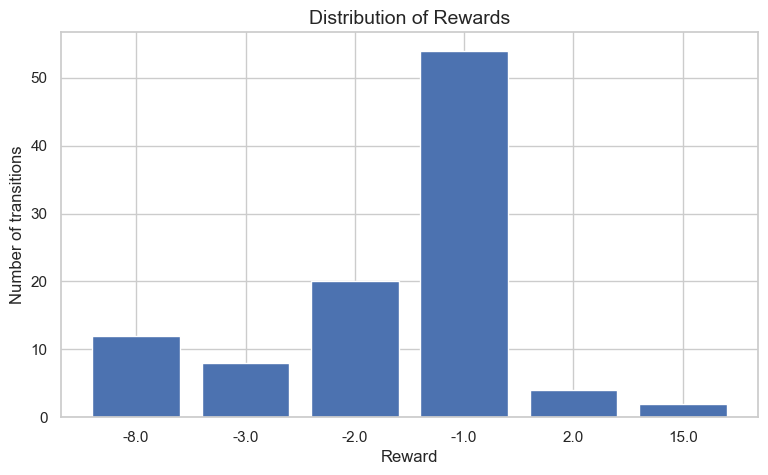

In [5]:
# Reward distribution
reward_distribution = (
    df["reward"]
    .value_counts()
    .sort_index()
    .rename_axis("Reward")
    .reset_index(name="Count")
)
reward_distribution["Percentage"] = (reward_distribution["Count"] / len(df) * 100).round(2)
display(reward_distribution)

plt.figure(figsize=(9, 5))
plt.bar(reward_distribution["Reward"].astype(str), reward_distribution["Count"])
plt.title("Distribution of Rewards")
plt.xlabel("Reward")
plt.ylabel("Number of transitions")
plt.show()

In [6]:
# Special states from the lab description
GRID_SIZE = 5
N_STATES = GRID_SIZE * GRID_SIZE
START_STATE = 0
GOAL_STATE = 24
FIRE_STATES = [7, 13, 18]
OBSTACLE_STATES = [6, 12]
BONUS_STATES = [4, 20]

state_type = {}
for s in range(N_STATES):
    if s == GOAL_STATE:
        state_type[s] = "Goal"
    elif s in FIRE_STATES:
        state_type[s] = "Fire"
    elif s in OBSTACLE_STATES:
        state_type[s] = "Obstacle"
    elif s in BONUS_STATES:
        state_type[s] = "Bonus"
    else:
        state_type[s] = "Normal"

special_states_df = pd.DataFrame({
    "State": list(range(N_STATES)),
    "Row": [s // GRID_SIZE for s in range(N_STATES)],
    "Column": [s % GRID_SIZE for s in range(N_STATES)],
    "Type": [state_type[s] for s in range(N_STATES)],
})
display(special_states_df)

# Dangerous and favorable transitions according to reward values
most_dangerous_transitions = df.sort_values("reward").head(12)
most_favorable_transitions = df.sort_values("reward", ascending=False).head(12)

print("Most dangerous transitions:")
display(most_dangerous_transitions)

print("Most favorable transitions:")
display(most_favorable_transitions)

,State,Row,Column,Type
0,0,0,0,Normal
1,1,0,1,Normal
2,2,0,2,Normal
3,3,0,3,Normal
4,4,0,4,Bonus
5,5,1,0,Normal
6,6,1,1,Obstacle
7,7,1,2,Fire
8,8,1,3,Normal
9,9,1,4,Normal


Most dangerous transitions:


,state,action,next_state,reward,done
9,2,down,7,-8.0,0
27,6,right,7,-8.0,0
53,13,down,18,-8.0,0
58,14,left,13,-8.0,0
48,12,up,7,-8.0,0
51,12,right,13,-8.0,0
34,8,left,7,-8.0,0
33,8,down,13,-8.0,0
92,23,up,18,-8.0,0
78,19,left,18,-8.0,0


Most favorable transitions:


,state,action,next_state,reward,done
77,19,down,24,15.0,1
95,23,right,24,15.0,1
15,3,right,4,2.0,0
36,9,up,4,2.0,0
61,15,down,20,2.0,0
86,21,left,20,2.0,0
10,2,left,1,-1.0,0
28,7,up,2,-1.0,0
32,8,up,3,-1.0,0
14,3,left,2,-1.0,0


### PART 1 — Answers

#### 1. What is the size of the dataset?

The dataset has **100 rows** and **5 columns**, so its shape is **(100, 5)**. Each row represents one transition: current state, action, next state, reward, and done.

#### 2. How many states and actions are present?

There are **25 states**, numbered from **0 to 24**, which matches the **5 × 5** grid. There are **4 actions**: **up**, **down**, **left**, and **right**.

#### 3. How many transitions per state?

Each state has **4 transitions**, one for each action. The table showed that all **25 states** have exactly **4 transitions**, so the transition table is complete.

#### 4. What is the distribution of rewards?

| Reward | Count | Meaning |
|---:|---:|---|
| -8 | 12 | Fire zone penalty |
| -3 | 8 | Obstacle penalty |
| -2 | 20 | Wall collision penalty |
| -1 | 54 | Normal movement cost |
| 2 | 4 | Bonus reward |
| 15 | 2 | Goal reward |

Most transitions have reward **-1**, meaning most moves are normal movements. The worst reward is **-8** for fire zones, and the best reward is **+15** for reaching the goal.

#### 5. Which states are most dangerous and most favorable?

The most dangerous states are the fire zones: **7**, **13**, and **18**, because moving into them gives reward **-8**. The obstacle states **6** and **12** are also bad because they give reward **-3**.

The most favorable state is the goal state **24**, with reward **+15**. The bonus states **4** and **20** are also favorable because they give reward **+2**.


## PART 2 — MDP Formulation

In [7]:
# Action encoding
ACTION_TO_INDEX = {action: i for i, action in enumerate(actions)}
INDEX_TO_ACTION = {i: action for action, i in ACTION_TO_INDEX.items()}

# Transition dictionary: (state, action) -> (next_state, reward, done)
transition_dict = {}
for _, row in df.iterrows():
    transition_dict[(int(row["state"]), row["action"])] = (
        int(row["next_state"]), float(row["reward"]), bool(row["done"])
    )

# Helper functions for grid indexing
def state_to_pos(state, grid_size=GRID_SIZE):
    return divmod(int(state), grid_size)

def pos_to_state(row, col, grid_size=GRID_SIZE):
    return int(row * grid_size + col)

# Environment step function
# Once the agent reaches the goal, the episode is considered finished.
def step(state, action):
    state = int(state)
    if state == GOAL_STATE:
        return GOAL_STATE, 0.0, True
    return transition_dict[(state, action)]

# MDP summary
mdp_summary = pd.DataFrame({
    "Element": ["State space", "Action space", "Reward function", "Transition function", "Terminal condition"],
    "Definition in this lab": [
        f"States 0 to {N_STATES - 1} arranged as a {GRID_SIZE}x{GRID_SIZE} grid",
        ", ".join(actions),
        "Reward received after taking an action and moving to the next state",
        "Deterministic mapping from (state, action) to (next_state, reward, done)",
        f"Episode ends when the agent reaches goal state {GOAL_STATE}"
    ]
})
display(mdp_summary)

# Check whether the transition function is deterministic
transition_counts = df.groupby(["state", "action"]).size().reset_index(name="Count")
print("Maximum number of rows for the same (state, action):", transition_counts["Count"].max())
print("Deterministic transition function:", transition_counts["Count"].max() == 1)

print("Terminal transitions where done = 1:")
display(df[df["done"] == 1])

,Element,Definition in this lab
0,State space,States 0 to 24 arranged as a 5x5 grid
1,Action space,"up, down, left, right"
2,Reward function,Reward received after taking an action and mov...
3,Transition function,"Deterministic mapping from (state, action) to ..."
4,Terminal condition,Episode ends when the agent reaches goal state 24


Maximum number of rows for the same (state, action): 1
Deterministic transition function: True
Terminal transitions where done = 1:


,state,action,next_state,reward,done
77,19,down,24,15.0,1
95,23,right,24,15.0,1


### PART 2 — Answers

#### 1. Define the state space, action space, reward function, and transition function.

The **state space** is **S = {0, 1, 2, ..., 24}**, arranged as a **5 × 5 grid**.

The **action space** is **A = {up, down, left, right}**.

The **reward function** gives the reward after each action:

- Goal state 24: **+15**
- Fire zones 7, 13, 18: **-8**
- Obstacles 6, 12: **-3**
- Bonus zones 4, 20: **+2**
- Wall collision: **-2**
- Normal move: **-1**

The **transition function** is **(state, action) -> (next_state, reward, done)**. It is deterministic because the same state and action always give the same result.

#### 2. Why is this problem a Markov Decision Process?

This problem is an MDP because the next state and reward depend only on the **current state** and the **chosen action**. The robot does not need the full history of previous states.

#### 3. What is the role of the done variable?

The `done` variable tells us if the episode has finished. Here, `done = 1` when the robot reaches the goal state **24**.

The terminal transitions are:

| State | Action | Next state | Reward | Done |
|---:|---|---:|---:|---:|
| 19 | down | 24 | 15 | 1 |
| 23 | right | 24 | 15 | 1 |

When `done = 1`, the robot has reached the rescue zone and the episode stops.


## PART 3 — Environment Understanding

In [8]:
# Create a grid table showing the type of each state
label_grid = np.empty((GRID_SIZE, GRID_SIZE), dtype=object)
for s in range(N_STATES):
    r, c = state_to_pos(s)
    label_grid[r, c] = f"{s}\n{state_type[s]}"

grid_display_df = pd.DataFrame(
    label_grid,
    index=[f"Row {i}" for i in range(GRID_SIZE)],
    columns=[f"Col {j}" for j in range(GRID_SIZE)]
)
display(grid_display_df)

,Col 0,Col 1,Col 2,Col 3,Col 4
Row 0,0\nNormal,1\nNormal,2\nNormal,3\nNormal,4\nBonus
Row 1,5\nNormal,6\nObstacle,7\nFire,8\nNormal,9\nNormal
Row 2,10\nNormal,11\nNormal,12\nObstacle,13\nFire,14\nNormal
Row 3,15\nNormal,16\nNormal,17\nNormal,18\nFire,19\nNormal
Row 4,20\nBonus,21\nNormal,22\nNormal,23\nNormal,24\nGoal


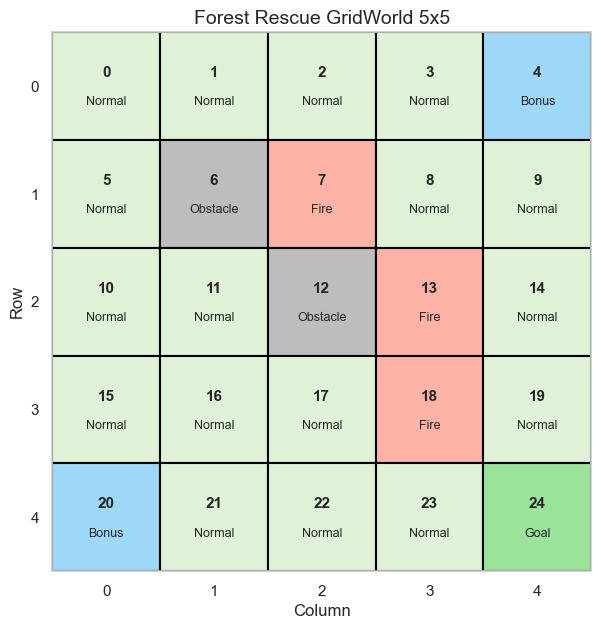

In [9]:
# Visual representation of the 5x5 environment
state_color_map = {
    "Normal": "#DFF2D8",
    "Goal": "#9BE39B",
    "Fire": "#FFB3A7",
    "Obstacle": "#BDBDBD",
    "Bonus": "#9ED7F7",
}

fig, ax = plt.subplots(figsize=(7, 7))
for s in range(N_STATES):
    r, c = state_to_pos(s)
    cell_type = state_type[s]
    rect = plt.Rectangle((c, GRID_SIZE - 1 - r), 1, 1,
                         facecolor=state_color_map[cell_type], edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(c + 0.5, GRID_SIZE - 1 - r + 0.62, str(s), ha="center", va="center", fontsize=11, weight="bold")
    ax.text(c + 0.5, GRID_SIZE - 1 - r + 0.35, cell_type, ha="center", va="center", fontsize=9)

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)
ax.set_xticks(np.arange(0.5, GRID_SIZE, 1))
ax.set_yticks(np.arange(0.5, GRID_SIZE, 1))
ax.set_xticklabels([str(i) for i in range(GRID_SIZE)])
ax.set_yticklabels([str(i) for i in reversed(range(GRID_SIZE))])
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_title("Forest Rescue GridWorld 5x5")
ax.set_aspect("equal")
plt.show()

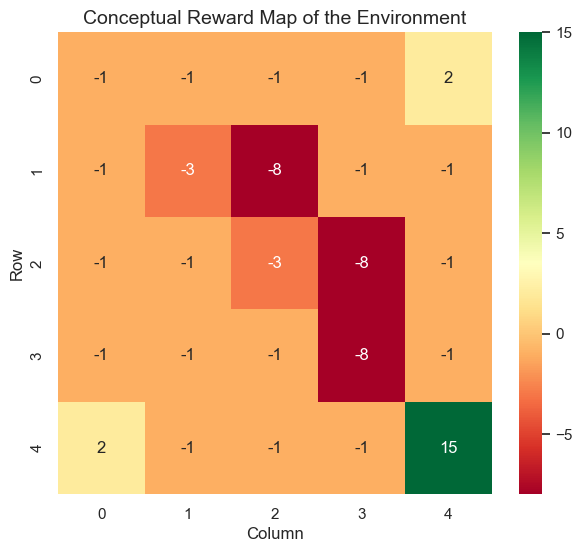

In [10]:
# Reward grid by destination/special states for environment understanding
# This grid summarizes the conceptual reward for landing in special cells.
conceptual_reward_grid = np.full((GRID_SIZE, GRID_SIZE), -1.0)
for s in FIRE_STATES:
    conceptual_reward_grid[state_to_pos(s)] = -8.0
for s in OBSTACLE_STATES:
    conceptual_reward_grid[state_to_pos(s)] = -3.0
for s in BONUS_STATES:
    conceptual_reward_grid[state_to_pos(s)] = 2.0
conceptual_reward_grid[state_to_pos(GOAL_STATE)] = 15.0

plt.figure(figsize=(7, 6))
sns.heatmap(conceptual_reward_grid, annot=True, fmt=".0f", cmap="RdYlGn", cbar=True,
            xticklabels=list(range(GRID_SIZE)), yticklabels=list(range(GRID_SIZE)))
plt.title("Conceptual Reward Map of the Environment")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

### PART 3 — Answers

#### 1. Where is the goal located?

The goal is located at **state 24**. In the grid, it is in **row 4, column 4**, which is the bottom-right corner. It gives reward **+15**.

#### 2. Where are obstacles and fire zones?

The obstacles are **state 6** and **state 12**. The fire zones are **state 7**, **state 13**, and **state 18**. The bonus zones are **state 4** and **state 20**.

#### 3. Which paths are risky?

Risky paths are the paths that move into fire zones or obstacles. Examples:

- From state **2**, action **down** leads to fire state **7**.
- From state **8**, action **left** leads to fire state **7**.
- From state **8**, action **down** leads to fire state **13**.
- From state **14**, action **left** leads to fire state **13**.
- From state **17**, action **right** leads to fire state **18**.
- From state **23**, action **up** leads to fire state **18**.

#### 4. Why is visualization important in RL?

Visualization makes the environment easier to understand. It shows where the goal, fire zones, obstacles, and bonus zones are. Without the grid, state numbers like 7, 13, or 24 are harder to interpret.


## PART 4 — State-Value Function (TD Learning)

In [11]:
# TD(0) value learning.
# V(s) estimates how good it is to be in state s under the current behavior strategy.
# The behavior strategy below is epsilon-greedy using one-step lookahead with the current V values.

VALID_START_STATES = [s for s in range(N_STATES) if s != GOAL_STATE]

def choose_action_from_values(V, state, epsilon, gamma, rng):
    """Epsilon-greedy action selection using one-step reward + gamma * V(next_state)."""
    if rng.random() < epsilon:
        return rng.choice(actions)
    scores = []
    for action in actions:
        next_state, reward, done = step(state, action)
        score = reward if done else reward + gamma * V[next_state]
        scores.append(score)
    max_score = np.max(scores)
    best_indices = np.flatnonzero(np.isclose(scores, max_score))
    return actions[int(rng.choice(best_indices))]

def td_value_learning(
    episodes=5000,
    alpha=0.10,
    gamma=0.95,
    epsilon_start=1.00,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    max_steps=100,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    V = np.zeros(N_STATES)
    logs = []
    epsilon = epsilon_start
    
    for episode in range(1, episodes + 1):
        state = int(rng.choice(VALID_START_STATES))
        total_reward = 0.0
        max_delta = 0.0
        reached_goal = False
        
        for t in range(max_steps):
            action = choose_action_from_values(V, state, epsilon, gamma, rng)
            next_state, reward, done = step(state, action)
            target = reward if done else reward + gamma * V[next_state]
            delta = target - V[state]
            V[state] += alpha * delta
            max_delta = max(max_delta, abs(delta))
            total_reward += reward
            state = next_state
            
            if done:
                reached_goal = True
                break
        
        logs.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": t + 1,
            "epsilon": epsilon,
            "max_value_change": max_delta,
            "reached_goal": reached_goal,
        })
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    return V, pd.DataFrame(logs)

V_td, td_log = td_value_learning()

value_table = pd.DataFrame({
    "State": np.arange(N_STATES),
    "Row": [state_to_pos(s)[0] for s in range(N_STATES)],
    "Column": [state_to_pos(s)[1] for s in range(N_STATES)],
    "Type": [state_type[s] for s in range(N_STATES)],
    "V(s)": V_td.round(4),
}).sort_values("State")

display(value_table)

,State,Row,Column,Type,V(s)
0,0,0,0,Normal,6.1282
1,1,0,1,Normal,7.3366
2,2,0,2,Normal,8.5389
3,3,0,3,Normal,9.6796
4,4,0,4,Bonus,8.4271
5,5,1,0,Normal,7.3857
6,6,1,1,Obstacle,6.4892
7,7,1,2,Fire,7.4377
8,8,1,3,Normal,8.7628
9,9,1,4,Normal,10.7149


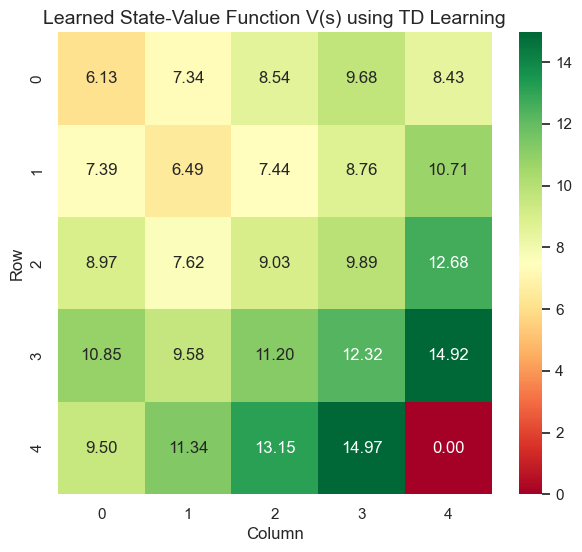

Highest value states:


,State,Row,Column,Type,V(s)
23,23,4,3,Normal,14.9688
19,19,3,4,Normal,14.9222
22,22,4,2,Normal,13.1503
14,14,2,4,Normal,12.6849
18,18,3,3,Fire,12.3152
21,21,4,1,Normal,11.3352
17,17,3,2,Normal,11.2043
15,15,3,0,Normal,10.8526


Lowest value states:


,State,Row,Column,Type,V(s)
24,24,4,4,Goal,0.0000
0,0,0,0,Normal,6.1282
6,6,1,1,Obstacle,6.4892
1,1,0,1,Normal,7.3366
5,5,1,0,Normal,7.3857
7,7,1,2,Fire,7.4377
11,11,2,1,Normal,7.6239
4,4,0,4,Bonus,8.4271


In [12]:
# Display the learned V(s) values as a 5x5 grid
V_grid = V_td.reshape(GRID_SIZE, GRID_SIZE)

plt.figure(figsize=(7, 6))
sns.heatmap(V_grid, annot=True, fmt=".2f", cmap="RdYlGn", cbar=True,
            xticklabels=list(range(GRID_SIZE)), yticklabels=list(range(GRID_SIZE)))
plt.title("Learned State-Value Function V(s) using TD Learning")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

print("Highest value states:")
display(value_table.sort_values("V(s)", ascending=False).head(8))

print("Lowest value states:")
display(value_table.sort_values("V(s)", ascending=True).head(8))

### PART 4 — Answers

#### 1. What does V(s) represent?

**V(s)** represents how good it is for the robot to be in a state. It estimates the expected long-term reward starting from that state.

#### 2. Which states have high values and low values?

The highest value states were mostly close to the goal:

| State | Type | V(s) |
|---:|---|---:|
| 23 | Normal | 14.9688 |
| 19 | Normal | 14.9222 |
| 22 | Normal | 13.1503 |
| 14 | Normal | 12.6849 |
| 18 | Fire | 12.3152 |
| 21 | Normal | 11.3352 |
| 17 | Normal | 11.2043 |
| 15 | Normal | 10.8526 |

The lowest value states were:

| State | Type | V(s) |
|---:|---|---:|
| 24 | Goal | 0.0000 |
| 0 | Normal | 6.1282 |
| 6 | Obstacle | 6.4892 |
| 1 | Normal | 7.3366 |
| 5 | Normal | 7.3857 |
| 7 | Fire | 7.4377 |
| 11 | Normal | 7.6239 |
| 4 | Bonus | 8.4271 |

The goal state has value **0** because it is terminal in this implementation.

#### 3. Why are some states negative even if they are not traps?

In this run, the learned state values are not negative, except the terminal goal value is **0**. In general, a normal state can have a low or negative value if it is far from the goal, close to fire, close to obstacles, or requires many steps with movement cost.

#### 4. How does distance to the goal influence V(s)?

States closer to the goal usually have higher values. For example, states **23** and **19** are next to the goal and have values around **14.97** and **14.92**. State **0** is far from the goal and has a lower value of **6.1282**.


## PART 5 — Convergence Analysis

,Metric,Value
0,Average reward - first 100 episodes,-78.160000
1,Average reward - last 100 episodes,13.740000
2,Average max value change - first 100 episodes,17.397309
3,Average max value change - last 100 episodes,1.369339
4,Goal-reaching rate - last 100 episodes,0.960000


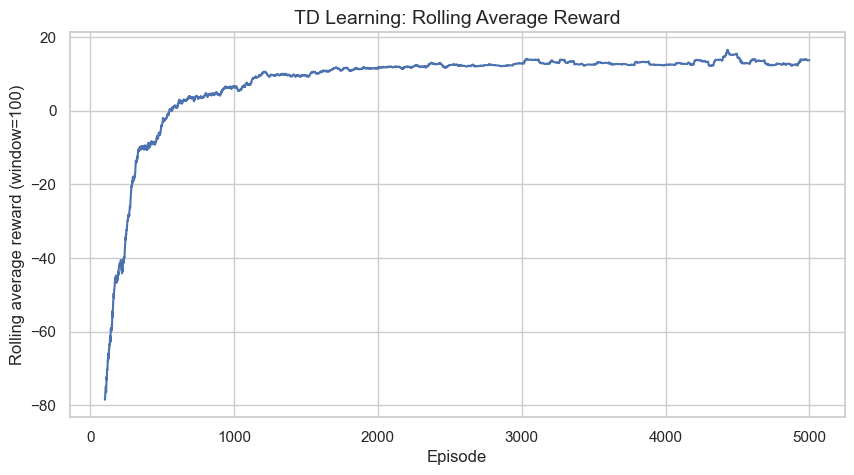

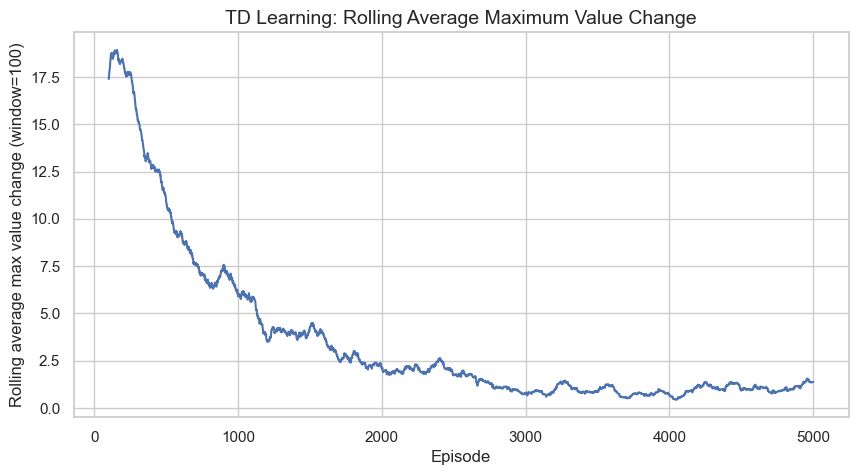

In [13]:
# Inspect TD learning progress
summary_td = pd.DataFrame({
    "Metric": [
        "Average reward - first 100 episodes",
        "Average reward - last 100 episodes",
        "Average max value change - first 100 episodes",
        "Average max value change - last 100 episodes",
        "Goal-reaching rate - last 100 episodes",
    ],
    "Value": [
        td_log["total_reward"].head(100).mean(),
        td_log["total_reward"].tail(100).mean(),
        td_log["max_value_change"].head(100).mean(),
        td_log["max_value_change"].tail(100).mean(),
        td_log["reached_goal"].tail(100).mean(),
    ]
})
display(summary_td)

plt.figure(figsize=(10, 5))
plt.plot(td_log["episode"], td_log["total_reward"].rolling(100).mean())
plt.title("TD Learning: Rolling Average Reward")
plt.xlabel("Episode")
plt.ylabel("Rolling average reward (window=100)")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(td_log["episode"], td_log["max_value_change"].rolling(100).mean())
plt.title("TD Learning: Rolling Average Maximum Value Change")
plt.xlabel("Episode")
plt.ylabel("Rolling average max value change (window=100)")
plt.show()

### PART 5 — Answers

#### 1. What does convergence mean in TD Learning?

Convergence means that the value estimates become stable. At the beginning, values change a lot. Later, the changes become smaller.

In the notebook, the average maximum value change decreased from **17.3973** in the first 100 episodes to **1.3693** in the last 100 episodes.

#### 2. What happens if alpha is too large or too small?

Alpha is the learning rate. If **alpha is too large**, learning can become unstable because values change too much. If **alpha is too small**, learning becomes very slow.

#### 3. Why is convergence important?

Convergence is important because it means the learned values are more reliable. In this lab, the average reward improved from **-78.16** in the first 100 episodes to **13.74** in the last 100 episodes. The goal-reaching rate in the last 100 episodes was **0.96**.


## PART 6 — Q-Learning

In [14]:
def choose_epsilon_greedy_action(Q, state, epsilon, rng):
    """Choose an action index using epsilon-greedy exploration."""
    if rng.random() < epsilon:
        return int(rng.integers(len(actions)))
    max_q = np.max(Q[state])
    best_indices = np.flatnonzero(np.isclose(Q[state], max_q))
    return int(rng.choice(best_indices))

def q_learning(
    episodes=8000,
    alpha=0.10,
    gamma=0.95,
    epsilon_start=1.00,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    max_steps=100,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    Q = np.zeros((N_STATES, len(actions)))
    logs = []
    epsilon = epsilon_start
    
    for episode in range(1, episodes + 1):
        state = int(rng.choice(VALID_START_STATES))
        total_reward = 0.0
        max_delta = 0.0
        fire_hits = 0
        obstacle_hits = 0
        wall_hits = 0
        reached_goal = False
        
        for t in range(max_steps):
            action_index = choose_epsilon_greedy_action(Q, state, epsilon, rng)
            action = actions[action_index]
            next_state, reward, done = step(state, action)
            
            target = reward if done else reward + gamma * np.max(Q[next_state])
            delta = target - Q[state, action_index]
            Q[state, action_index] += alpha * delta
            max_delta = max(max_delta, abs(delta))
            
            total_reward += reward
            if reward == -8:
                fire_hits += 1
            elif reward == -3:
                obstacle_hits += 1
            elif reward == -2:
                wall_hits += 1
            
            state = next_state
            if done:
                reached_goal = True
                break
        
        logs.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": t + 1,
            "epsilon": epsilon,
            "max_q_change": max_delta,
            "fire_hits": fire_hits,
            "obstacle_hits": obstacle_hits,
            "wall_hits": wall_hits,
            "reached_goal": reached_goal,
        })
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    return Q, pd.DataFrame(logs)

Q_qlearning, qlearning_log = q_learning()

q_table_df = pd.DataFrame(Q_qlearning, columns=actions)
q_table_df.index.name = "State"
display(q_table_df.round(3))

,up,down,left,right
State,,,,
0,4.378,7.014,4.017,6.503
1,5.532,4.664,5.292,8.436
2,7.394,0.073,6.903,9.932
3,8.929,8.507,8.433,11.508
4,7.507,10.008,9.932,7.508
5,5.642,8.436,6.004,4.987
6,4.362,7.082,3.647,0.034
7,8.313,5.013,5.059,8.508
8,9.925,3.008,0.082,10.008


,Metric,Value
0,Average reward - last 1000 episodes,12.192
1,Average steps - last 1000 episodes,4.432
2,Goal-reaching rate - last 1000 episodes,1.000
3,Average fire hits - last 1000 episodes,0.027
4,Average obstacle hits - last 1000 episodes,0.015
5,Average wall hits - last 1000 episodes,0.051


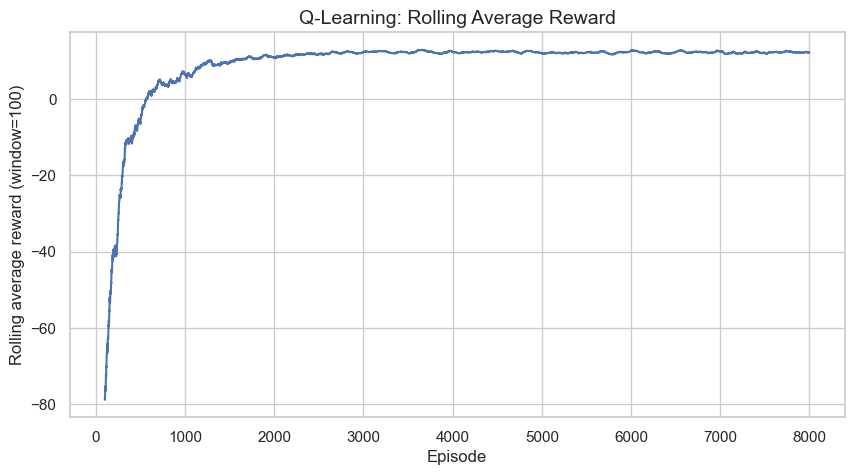

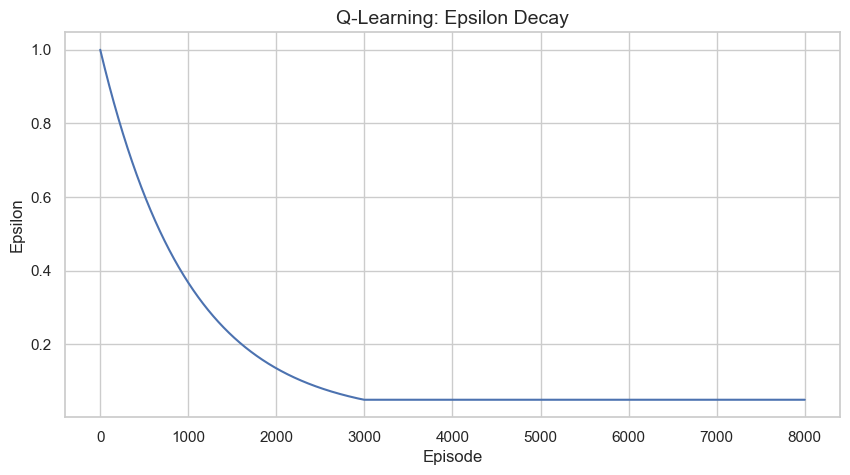

In [15]:
# Q-learning training summary
qlearning_summary = pd.DataFrame({
    "Metric": [
        "Average reward - last 1000 episodes",
        "Average steps - last 1000 episodes",
        "Goal-reaching rate - last 1000 episodes",
        "Average fire hits - last 1000 episodes",
        "Average obstacle hits - last 1000 episodes",
        "Average wall hits - last 1000 episodes",
    ],
    "Value": [
        qlearning_log["total_reward"].tail(1000).mean(),
        qlearning_log["steps"].tail(1000).mean(),
        qlearning_log["reached_goal"].tail(1000).mean(),
        qlearning_log["fire_hits"].tail(1000).mean(),
        qlearning_log["obstacle_hits"].tail(1000).mean(),
        qlearning_log["wall_hits"].tail(1000).mean(),
    ]
})
display(qlearning_summary)

plt.figure(figsize=(10, 5))
plt.plot(qlearning_log["episode"], qlearning_log["total_reward"].rolling(100).mean())
plt.title("Q-Learning: Rolling Average Reward")
plt.xlabel("Episode")
plt.ylabel("Rolling average reward (window=100)")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(qlearning_log["episode"], qlearning_log["epsilon"])
plt.title("Q-Learning: Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

In [16]:
# Inspect best actions in important states near the goal and near fire zones
important_states = sorted(set([19, 23, 2, 8, 12, 17, 22]))

def best_action_table(Q, selected_states):
    rows = []
    for s in selected_states:
        best_index = int(np.argmax(Q[s]))
        rows.append({
            "State": s,
            "Type": state_type[s],
            "Best action": actions[best_index],
            "Best Q-value": Q[s, best_index],
            **{f"Q({a})": Q[s, i] for i, a in enumerate(actions)}
        })
    return pd.DataFrame(rows)

qlearning_important_states = best_action_table(Q_qlearning, important_states)
display(qlearning_important_states.round(3))

,State,Type,Best action,Best Q-value,Q(up),Q(down),Q(left),Q(right)
0,2,Normal,right,9.932,7.394,0.073,6.903,9.932
1,8,Normal,right,10.008,9.925,3.008,0.082,10.008
2,12,Obstacle,down,10.008,-0.027,10.008,5.389,1.934
3,17,Normal,down,11.587,8.008,11.587,8.508,4.587
4,19,Normal,down,15.000,11.587,15.000,4.587,12.250
5,22,Normal,right,13.250,10.008,10.587,10.008,13.250
6,23,Normal,right,15.000,4.587,12.250,11.587,15.000


### PART 6 — Answers

#### 1. What does Q(s, a) represent?

**Q(s, a)** represents the value of taking action **a** in state **s**. It estimates the long-term reward expected after choosing that action.

#### 2. Why is Q-learning useful for control?

Q-learning is useful because it learns the value of each action in each state. After learning, the robot can choose the action with the highest Q-value, so the Q-table gives a policy directly.

#### 3. What is the best action in a state near the goal and a state near fire?

Near the goal:

- State **23**: best action **right**, Q-value **15.000**.
- State **19**: best action **down**, Q-value **15.000**.

Near fire zones:

- State **2**: best action **right**, avoiding fire state 7.
- State **8**: best action **right**, avoiding fire states 7 and 13.
- State **17**: best action **down**, avoiding fire state 18 on the right.

#### 4. Why do some actions have very low values?

Some actions have low values because they lead to bad results such as fire, obstacles, wall collisions, or longer paths. For example, moving into a fire zone gives reward **-8**, so actions leading to fire become less attractive.


## PART 7 — Policy Extraction

In [17]:
# Extract greedy policy from Q-table
arrow_map = {
    "up": "up ->",
    "down": "down ->",
    "left": "left ->",
    "right": "right ->",
}

def extract_policy(Q):
    policy = []
    for s in range(N_STATES):
        if s == GOAL_STATE:
            policy.append("G")
        elif s in FIRE_STATES:
            policy.append("F")
        elif s in OBSTACLE_STATES:
            policy.append("O")
        else:
            best_action = actions[int(np.argmax(Q[s]))]
            policy.append(arrow_map[best_action])
    return np.array(policy, dtype=object)

qlearning_policy_symbols = extract_policy(Q_qlearning)
qlearning_policy_grid = qlearning_policy_symbols.reshape(GRID_SIZE, GRID_SIZE)

policy_grid_df = pd.DataFrame(
    qlearning_policy_grid,
    index=[f"Row {i}" for i in range(GRID_SIZE)],
    columns=[f"Col {j}" for j in range(GRID_SIZE)]
)
display(policy_grid_df)

,Col 0,Col 1,Col 2,Col 3,Col 4
Row 0,down ->,right ->,right ->,right ->,down ->
Row 1,down ->,O,F,right ->,down ->
Row 2,down ->,down ->,O,F,down ->
Row 3,down ->,down ->,down ->,F,down ->
Row 4,right ->,right ->,right ->,right ->,G


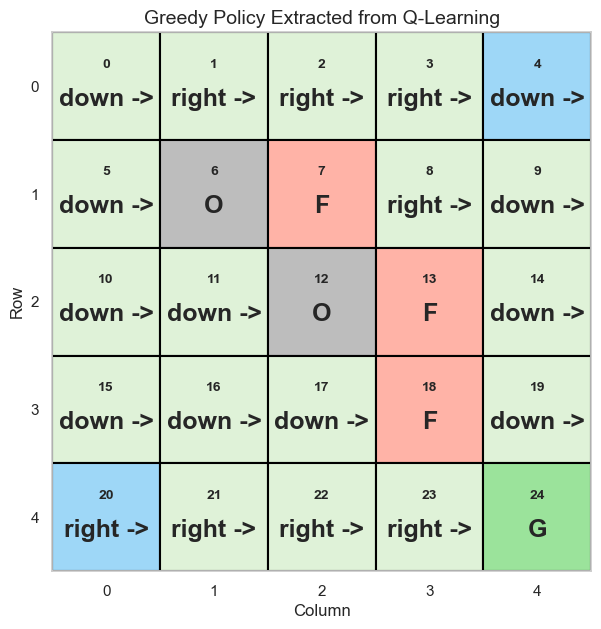

In [18]:
def plot_policy_grid(policy_symbols, title):
    fig, ax = plt.subplots(figsize=(7, 7))
    for s in range(N_STATES):
        r, c = state_to_pos(s)
        cell_type = state_type[s]
        rect = plt.Rectangle((c, GRID_SIZE - 1 - r), 1, 1,
                             facecolor=state_color_map[cell_type], edgecolor="black", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(c + 0.5, GRID_SIZE - 1 - r + 0.70, str(s), ha="center", va="center", fontsize=10, weight="bold")
        ax.text(c + 0.5, GRID_SIZE - 1 - r + 0.38, policy_symbols[s], ha="center", va="center", fontsize=18, weight="bold")
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_xticks(np.arange(0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(0.5, GRID_SIZE, 1))
    ax.set_xticklabels([str(i) for i in range(GRID_SIZE)])
    ax.set_yticklabels([str(i) for i in reversed(range(GRID_SIZE))])
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.show()

plot_policy_grid(qlearning_policy_symbols, "Greedy Policy Extracted from Q-Learning")

In [19]:
def simulate_greedy_policy(Q, start_state=START_STATE, max_steps=50):
    state = start_state
    total_reward = 0.0
    rows = []
    
    for step_number in range(max_steps):
        if state == GOAL_STATE:
            break
        action_index = int(np.argmax(Q[state]))
        action = actions[action_index]
        next_state, reward, done = step(state, action)
        rows.append({
            "Step": step_number,
            "State": state,
            "Action": action,
            "Next state": next_state,
            "Reward": reward,
            "Done": done,
        })
        total_reward += reward
        state = next_state
        if done:
            break
    
    path_df = pd.DataFrame(rows)
    reached_goal = bool(len(path_df) > 0 and path_df.iloc[-1]["Done"])
    return path_df, total_reward, reached_goal

qlearning_path_df, qlearning_path_reward, qlearning_reached_goal = simulate_greedy_policy(Q_qlearning)

display(qlearning_path_df)
print("Q-learning greedy path total reward:", qlearning_path_reward)
print("Q-learning reached goal:", qlearning_reached_goal)
print("Q-learning greedy path length:", len(qlearning_path_df))
print("Fire hits in path:", int((qlearning_path_df["Reward"] == -8).sum()) if len(qlearning_path_df) else 0)
print("Obstacle hits in path:", int((qlearning_path_df["Reward"] == -3).sum()) if len(qlearning_path_df) else 0)
print("Wall hits in path:", int((qlearning_path_df["Reward"] == -2).sum()) if len(qlearning_path_df) else 0)

,Step,State,Action,Next state,Reward,Done
0,0,0,down,5,-1.0,False
1,1,5,down,10,-1.0,False
2,2,10,down,15,-1.0,False
3,3,15,down,20,2.0,False
4,4,20,right,21,-1.0,False
5,5,21,right,22,-1.0,False
6,6,22,right,23,-1.0,False
7,7,23,right,24,15.0,True


Q-learning greedy path total reward: 11.0
Q-learning reached goal: True
Q-learning greedy path length: 8
Fire hits in path: 0
Obstacle hits in path: 0
Wall hits in path: 0


### PART 7 — Answers

#### 1. How is the policy derived from the Q-table?

The policy is derived by choosing the action with the highest Q-value for each state. This is called a greedy policy.

#### 2. Does the policy avoid fire zones, avoid obstacles, and reach the goal efficiently?

Yes. The Q-learning greedy path was:

**0 -> 5 -> 10 -> 15 -> 20 -> 21 -> 22 -> 23 -> 24**

| Metric | Value |
|---|---:|
| Total reward | 11.0 |
| Path length | 8 |
| Reached goal | True |
| Fire hits | 0 |
| Obstacle hits | 0 |
| Wall hits | 0 |

So the robot reached the goal without hitting fire, obstacles, or walls. It also used the bonus state **20**.

#### 3. What would a bad policy look like?

A bad policy would move into fire zones, obstacles, or walls. It may also make the robot move in loops without reaching the goal.


## PART 8 — Exploration vs Exploitation

,epsilon,demo_state,up,down,left,right
0,0.0,23,0,0,0,1000
1,0.1,23,22,29,29,920
2,0.5,23,140,113,138,609
3,1.0,23,261,264,217,258


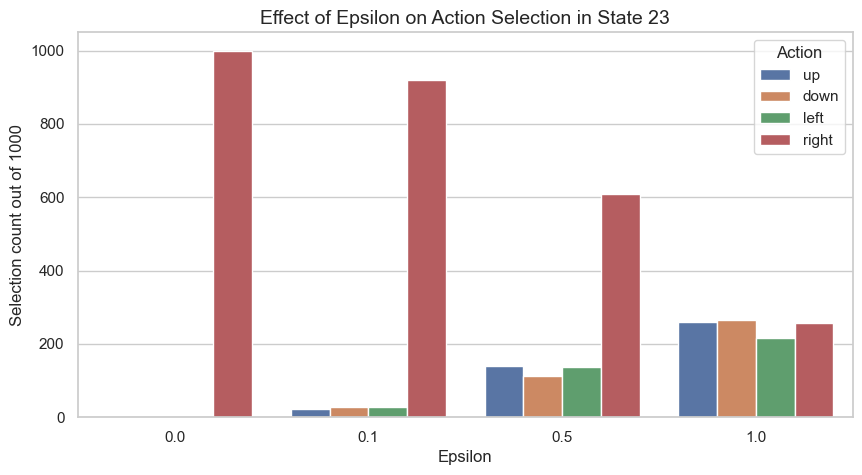

In [20]:
# Demonstrate how epsilon affects action selection for one state.
# A low epsilon mainly exploits the best action; a high epsilon explores more randomly.
demo_state = 23  # near the goal; right should usually be strong because it reaches state 24
rng = np.random.default_rng(RANDOM_STATE)

epsilon_demo_rows = []
for eps in [0.0, 0.1, 0.5, 1.0]:
    counts = {a: 0 for a in actions}
    for _ in range(1000):
        action_index = choose_epsilon_greedy_action(Q_qlearning, demo_state, eps, rng)
        counts[actions[action_index]] += 1
    row = {"epsilon": eps, "demo_state": demo_state}
    row.update(counts)
    epsilon_demo_rows.append(row)

epsilon_demo_df = pd.DataFrame(epsilon_demo_rows)
display(epsilon_demo_df)

epsilon_demo_melted = epsilon_demo_df.melt(
    id_vars=["epsilon", "demo_state"],
    value_vars=actions,
    var_name="Action",
    value_name="Selection count"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=epsilon_demo_melted, x="epsilon", y="Selection count", hue="Action")
plt.title(f"Effect of Epsilon on Action Selection in State {demo_state}")
plt.xlabel("Epsilon")
plt.ylabel("Selection count out of 1000")
plt.show()

### PART 8 — Answers

#### 1. Explain epsilon-greedy strategy.

Epsilon-greedy balances exploration and exploitation. With probability **epsilon**, the agent chooses a random action. With probability **1 - epsilon**, it chooses the best action from the Q-table.

#### 2. What happens if epsilon = 0 or epsilon = 1?

If **epsilon = 0**, the agent always exploits. In the demo for state **23**, action **right** was selected **1000 times out of 1000**.

If **epsilon = 1**, the agent always explores randomly. For state 23, the action counts were almost random:

| Action | Count |
|---|---:|
| up | 261 |
| down | 264 |
| left | 217 |
| right | 258 |

#### 3. Why is exploration critical in this environment?

Exploration is important because the robot needs to discover the goal, fire zones, obstacles, bonus zones, and safe paths.

#### 4. What risk occurs without exploration?

Without exploration, the robot may get stuck with a bad early policy and may never discover a safer or better path.


## PART 9 — SARSA

In [21]:
def sarsa_learning(
    episodes=8000,
    alpha=0.10,
    gamma=0.95,
    epsilon_start=1.00,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    max_steps=100,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    Q = np.zeros((N_STATES, len(actions)))
    logs = []
    epsilon = epsilon_start
    
    for episode in range(1, episodes + 1):
        state = int(rng.choice(VALID_START_STATES))
        action_index = choose_epsilon_greedy_action(Q, state, epsilon, rng)
        total_reward = 0.0
        max_delta = 0.0
        fire_hits = 0
        obstacle_hits = 0
        wall_hits = 0
        reached_goal = False
        
        for t in range(max_steps):
            action = actions[action_index]
            next_state, reward, done = step(state, action)
            
            if done:
                target = reward
                next_action_index = None
            else:
                next_action_index = choose_epsilon_greedy_action(Q, next_state, epsilon, rng)
                target = reward + gamma * Q[next_state, next_action_index]
            
            delta = target - Q[state, action_index]
            Q[state, action_index] += alpha * delta
            max_delta = max(max_delta, abs(delta))
            
            total_reward += reward
            if reward == -8:
                fire_hits += 1
            elif reward == -3:
                obstacle_hits += 1
            elif reward == -2:
                wall_hits += 1
            
            state = next_state
            if done:
                reached_goal = True
                break
            action_index = next_action_index
        
        logs.append({
            "episode": episode,
            "total_reward": total_reward,
            "steps": t + 1,
            "epsilon": epsilon,
            "max_q_change": max_delta,
            "fire_hits": fire_hits,
            "obstacle_hits": obstacle_hits,
            "wall_hits": wall_hits,
            "reached_goal": reached_goal,
        })
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    return Q, pd.DataFrame(logs)

Q_sarsa, sarsa_log = sarsa_learning()

sarsa_q_table_df = pd.DataFrame(Q_sarsa, columns=actions)
sarsa_q_table_df.index.name = "State"
display(sarsa_q_table_df.round(3))

,up,down,left,right
State,,,,
0,-9.906,6.249,-2.927,-9.764
1,-8.803,-8.748,-4.173,7.167
2,-4.547,-8.041,-6.084,8.944
3,4.944,2.922,1.322,10.751
4,4.642,9.617,5.747,5.088
5,-4.805,7.864,0.031,-3.803
6,-4.018,6.074,-3.954,-7.837
7,-4.116,-6.522,-4.908,8.110
8,2.429,-1.509,-7.324,9.451


,Metric,Value
0,Average reward - last 1000 episodes,12.380
1,Average steps - last 1000 episodes,4.332
2,Goal-reaching rate - last 1000 episodes,1.000
3,Average fire hits - last 1000 episodes,0.018
4,Average obstacle hits - last 1000 episodes,0.007
5,Average wall hits - last 1000 episodes,0.051


,State,Type,Best action,Best Q-value,Q(up),Q(down),Q(left),Q(right)
0,2,Normal,right,8.944,-4.547,-8.041,-6.084,8.944
1,8,Normal,right,9.451,2.429,-1.509,-7.324,9.451
2,12,Obstacle,down,9.739,-6.167,9.739,-2.024,-1.893
3,17,Normal,down,11.191,3.384,11.191,2.831,2.573
4,19,Normal,down,15.000,10.113,15.000,2.863,12.047
5,22,Normal,right,13.172,9.544,10.355,9.428,13.172
6,23,Normal,right,15.000,3.130,12.134,11.098,15.000


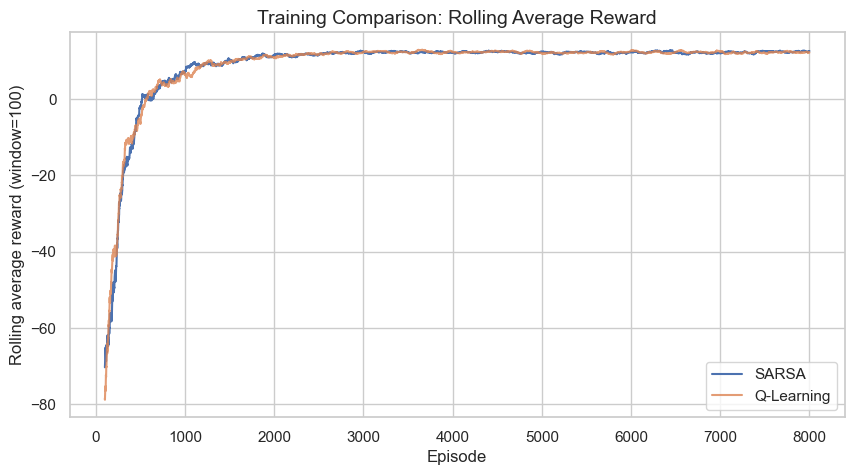

In [22]:
# SARSA training summary and important states
sarsa_summary = pd.DataFrame({
    "Metric": [
        "Average reward - last 1000 episodes",
        "Average steps - last 1000 episodes",
        "Goal-reaching rate - last 1000 episodes",
        "Average fire hits - last 1000 episodes",
        "Average obstacle hits - last 1000 episodes",
        "Average wall hits - last 1000 episodes",
    ],
    "Value": [
        sarsa_log["total_reward"].tail(1000).mean(),
        sarsa_log["steps"].tail(1000).mean(),
        sarsa_log["reached_goal"].tail(1000).mean(),
        sarsa_log["fire_hits"].tail(1000).mean(),
        sarsa_log["obstacle_hits"].tail(1000).mean(),
        sarsa_log["wall_hits"].tail(1000).mean(),
    ]
})
display(sarsa_summary)

sarsa_important_states = best_action_table(Q_sarsa, important_states)
display(sarsa_important_states.round(3))

plt.figure(figsize=(10, 5))
plt.plot(sarsa_log["episode"], sarsa_log["total_reward"].rolling(100).mean(), label="SARSA")
plt.plot(qlearning_log["episode"], qlearning_log["total_reward"].rolling(100).mean(), label="Q-Learning", alpha=0.8)
plt.title("Training Comparison: Rolling Average Reward")
plt.xlabel("Episode")
plt.ylabel("Rolling average reward (window=100)")
plt.legend()
plt.show()

,Col 0,Col 1,Col 2,Col 3,Col 4
Row 0,down ->,right ->,right ->,right ->,down ->
Row 1,down ->,O,F,right ->,down ->
Row 2,down ->,down ->,O,F,down ->
Row 3,down ->,down ->,down ->,F,down ->
Row 4,right ->,right ->,right ->,right ->,G


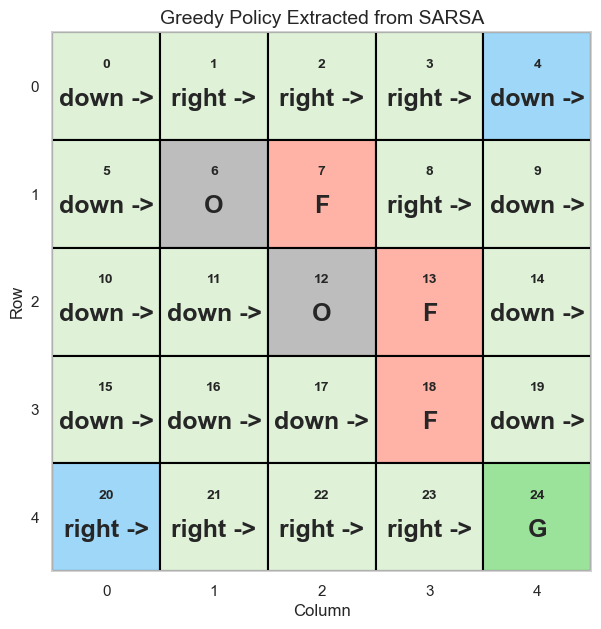

,Step,State,Action,Next state,Reward,Done
0,0,0,down,5,-1.0,False
1,1,5,down,10,-1.0,False
2,2,10,down,15,-1.0,False
3,3,15,down,20,2.0,False
4,4,20,right,21,-1.0,False
5,5,21,right,22,-1.0,False
6,6,22,right,23,-1.0,False
7,7,23,right,24,15.0,True


SARSA greedy path total reward: 11.0
SARSA reached goal: True
SARSA greedy path length: 8
Fire hits in path: 0
Obstacle hits in path: 0
Wall hits in path: 0


In [23]:
# Extract and visualize SARSA policy
sarsa_policy_symbols = extract_policy(Q_sarsa)
sarsa_policy_grid = sarsa_policy_symbols.reshape(GRID_SIZE, GRID_SIZE)

sarsa_policy_grid_df = pd.DataFrame(
    sarsa_policy_grid,
    index=[f"Row {i}" for i in range(GRID_SIZE)],
    columns=[f"Col {j}" for j in range(GRID_SIZE)]
)
display(sarsa_policy_grid_df)

plot_policy_grid(sarsa_policy_symbols, "Greedy Policy Extracted from SARSA")

sarsa_path_df, sarsa_path_reward, sarsa_reached_goal = simulate_greedy_policy(Q_sarsa)
display(sarsa_path_df)
print("SARSA greedy path total reward:", sarsa_path_reward)
print("SARSA reached goal:", sarsa_reached_goal)
print("SARSA greedy path length:", len(sarsa_path_df))
print("Fire hits in path:", int((sarsa_path_df["Reward"] == -8).sum()) if len(sarsa_path_df) else 0)
print("Obstacle hits in path:", int((sarsa_path_df["Reward"] == -3).sum()) if len(sarsa_path_df) else 0)
print("Wall hits in path:", int((sarsa_path_df["Reward"] == -2).sum()) if len(sarsa_path_df) else 0)

### PART 9 — Answers

#### 1. What is the difference between Q-learning and SARSA?

Q-learning is **off-policy**. It updates using the best possible next action: **max Q(s', a')**.

SARSA is **on-policy**. It updates using the action actually chosen next: **Q(s', a')**.

#### 2. Which algorithm is more cautious and which is more aggressive?

Usually, **SARSA** is more cautious because it learns from the actual actions taken, including exploration. **Q-learning** is more aggressive because it assumes the best future action will be selected.

#### 3. In a dangerous environment with fire zones, which is preferable?

SARSA can be preferable in dangerous environments because it is more cautious. In this run, both algorithms learned the same final path, but SARSA had slightly fewer dangerous hits during training.

| Metric | Q-learning | SARSA |
|---|---:|---:|
| Average reward, last 1000 | 12.192 | 12.380 |
| Average steps, last 1000 | 4.432 | 4.332 |
| Goal-reaching rate, last 1000 | 1.000 | 1.000 |
| Average fire hits, last 1000 | 0.027 | 0.018 |
| Average obstacle hits, last 1000 | 0.015 | 0.007 |
| Average wall hits, last 1000 | 0.051 | 0.051 |

So SARSA was slightly safer during training.


## PART 11 — Model Comparison

In [24]:
# Compare best actions from Q-learning and SARSA for all states
comparison_rows = []
for s in range(N_STATES):
    if s == GOAL_STATE:
        q_action = "Goal"
        sarsa_action = "Goal"
    elif s in FIRE_STATES:
        q_action = "Fire state"
        sarsa_action = "Fire state"
    elif s in OBSTACLE_STATES:
        q_action = "Obstacle"
        sarsa_action = "Obstacle"
    else:
        q_action = actions[int(np.argmax(Q_qlearning[s]))]
        sarsa_action = actions[int(np.argmax(Q_sarsa[s]))]
    comparison_rows.append({
        "State": s,
        "Type": state_type[s],
        "Best action Q-learning": q_action,
        "Best action SARSA": sarsa_action,
        "Difference": "Same" if q_action == sarsa_action else "Different",
    })

policy_comparison_df = pd.DataFrame(comparison_rows)
display(policy_comparison_df)

print("Number of states with same action:", (policy_comparison_df["Difference"] == "Same").sum())
print("Number of states with different action:", (policy_comparison_df["Difference"] == "Different").sum())

,State,Type,Best action Q-learning,Best action SARSA,Difference
0,0,Normal,down,down,Same
1,1,Normal,right,right,Same
2,2,Normal,right,right,Same
3,3,Normal,right,right,Same
4,4,Bonus,down,down,Same
5,5,Normal,down,down,Same
6,6,Obstacle,Obstacle,Obstacle,Same
7,7,Fire,Fire state,Fire state,Same
8,8,Normal,right,right,Same
9,9,Normal,down,down,Same


Number of states with same action: 25
Number of states with different action: 0


In [25]:
# Compare greedy paths from the start state
path_comparison_df = pd.DataFrame([
    {
        "Algorithm": "Q-Learning",
        "Reached goal": qlearning_reached_goal,
        "Path length": len(qlearning_path_df),
        "Total reward": qlearning_path_reward,
        "Fire hits": int((qlearning_path_df["Reward"] == -8).sum()) if len(qlearning_path_df) else 0,
        "Obstacle hits": int((qlearning_path_df["Reward"] == -3).sum()) if len(qlearning_path_df) else 0,
        "Wall hits": int((qlearning_path_df["Reward"] == -2).sum()) if len(qlearning_path_df) else 0,
        "Path": " -> ".join(qlearning_path_df["State"].astype(str).tolist() + ([str(GOAL_STATE)] if qlearning_reached_goal else [])),
    },
    {
        "Algorithm": "SARSA",
        "Reached goal": sarsa_reached_goal,
        "Path length": len(sarsa_path_df),
        "Total reward": sarsa_path_reward,
        "Fire hits": int((sarsa_path_df["Reward"] == -8).sum()) if len(sarsa_path_df) else 0,
        "Obstacle hits": int((sarsa_path_df["Reward"] == -3).sum()) if len(sarsa_path_df) else 0,
        "Wall hits": int((sarsa_path_df["Reward"] == -2).sum()) if len(sarsa_path_df) else 0,
        "Path": " -> ".join(sarsa_path_df["State"].astype(str).tolist() + ([str(GOAL_STATE)] if sarsa_reached_goal else [])),
    },
])
display(path_comparison_df)

,Algorithm,Reached goal,Path length,Total reward,Fire hits,Obstacle hits,Wall hits,Path
0,Q-Learning,True,8,11.0,0,0,0,0 -> 5 -> 10 -> 15 -> 20 -> 21 -> 22 -> 23 -> 24
1,SARSA,True,8,11.0,0,0,0,0 -> 5 -> 10 -> 15 -> 20 -> 21 -> 22 -> 23 -> 24


In [26]:
# Final comparison of training performance over the last 1000 episodes
training_comparison_df = pd.DataFrame([
    {
        "Algorithm": "Q-Learning",
        "Average reward (last 1000)": qlearning_log["total_reward"].tail(1000).mean(),
        "Average steps (last 1000)": qlearning_log["steps"].tail(1000).mean(),
        "Goal-reaching rate (last 1000)": qlearning_log["reached_goal"].tail(1000).mean(),
        "Average fire hits (last 1000)": qlearning_log["fire_hits"].tail(1000).mean(),
        "Average obstacle hits (last 1000)": qlearning_log["obstacle_hits"].tail(1000).mean(),
        "Average wall hits (last 1000)": qlearning_log["wall_hits"].tail(1000).mean(),
    },
    {
        "Algorithm": "SARSA",
        "Average reward (last 1000)": sarsa_log["total_reward"].tail(1000).mean(),
        "Average steps (last 1000)": sarsa_log["steps"].tail(1000).mean(),
        "Goal-reaching rate (last 1000)": sarsa_log["reached_goal"].tail(1000).mean(),
        "Average fire hits (last 1000)": sarsa_log["fire_hits"].tail(1000).mean(),
        "Average obstacle hits (last 1000)": sarsa_log["obstacle_hits"].tail(1000).mean(),
        "Average wall hits (last 1000)": sarsa_log["wall_hits"].tail(1000).mean(),
    },
])
display(training_comparison_df.round(4))

,Algorithm,Average reward (last 1000),Average steps (last 1000),Goal-reaching rate (last 1000),Average fire hits (last 1000),Average obstacle hits (last 1000),Average wall hits (last 1000)
0,Q-Learning,12.192,4.432,1.0,0.027,0.015,0.051
1,SARSA,12.380,4.332,1.0,0.018,0.007,0.051


### PART 11 — Answers

#### 1. Do both algorithms give the same policy?

Yes. In this run, both Q-learning and SARSA gave the same final policy.

- States with the same action: **25**
- States with different actions: **0**

Both algorithms learned the same path:

**0 -> 5 -> 10 -> 15 -> 20 -> 21 -> 22 -> 23 -> 24**

#### 2. Why might they differ?

They might differ because Q-learning and SARSA update their Q-values differently. Q-learning uses the best future action, while SARSA uses the action actually chosen during training.

#### 3. Which one is safer?

In the final greedy policy, both algorithms were equally safe because both found the same path.

Both paths had **0 fire hits**, **0 obstacle hits**, **0 wall hits**, total reward **11.0**, and path length **8**.

During training, SARSA was slightly safer because it had fewer average fire and obstacle hits in the last 1000 episodes.


## Final Conclusion

In this lab, we studied a reinforcement learning problem using a **5 × 5 Forest Rescue GridWorld** environment.

The environment has **25 states** and **4 actions**: up, down, left, and right. The goal is to reach the rescue zone at state **24**, while avoiding fire zones, obstacles, and wall collisions.

The reward system guides the robot:

- Goal state 24 gives **+15**
- Fire zones give **-8**
- Obstacles give **-3**
- Wall collisions give **-2**
- Normal moves give **-1**
- Bonus zones give **+2**

TD Learning was used to learn the state-value function **V(s)**. The learned values showed that states close to the goal, such as **23** and **19**, had the highest values.

Q-learning learned a safe policy that reached the goal using this path:

**0 -> 5 -> 10 -> 15 -> 20 -> 21 -> 22 -> 23 -> 24**

This path reached the goal with total reward **11.0**, path length **8**, and **0** fire, obstacle, and wall hits.

SARSA was also applied and produced the same final policy as Q-learning. However, during training, SARSA was slightly safer because it had fewer average fire and obstacle hits.

Overall, both algorithms learned a good policy. The robot learned to avoid dangerous zones, use a safe path, collect the bonus at state **20**, and reach the rescue zone at state **24**.

A limitation is that this is a small tabular environment. Real rescue problems are larger and less predictable. The results also depend on hyperparameters such as alpha, gamma, epsilon, and the number of training episodes.
